## Generates the synthetic Data for Training the Model

First we need to do our imports and get our master csv file.

In [1]:
import pandas as pd
import nvdlib
import pprint
import json
import os
import ast
import re
from dotenv import load_dotenv
import urllib.parse

# langchain imports
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain.tools import tool
from langchain_core.runnables import RunnableLambda
from pydantic import BaseModel, Field
from typing import Literal
from langchain.agents import create_agent

# for displaying graphs
from IPython.display import Image, display

# import playwright tool
import playwright_tool

/Users/dzurec/ping/ai-module/synthetic-agentic/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Define the model. We also ask for JSON formatting as well, which uses Ollama's native JSON feature to force clean JSON output.

In [2]:
llm = ChatOllama(model="gpt-oss:20b", format="json")

In [3]:
master_df = pd.read_csv('normal_master.csv')
master_df.head()

,model_name,vendor,device_type,keyword_lookup
0,Xbox Series X,Microsoft,Gaming Console,Microsoft Xbox
1,Nintendo Switch,Nintendo,Gaming Console,Nintendo Switch
2,PlayStation 5,Sony,Gaming Console,Sony PlayStation
3,Plex Media Server,Plex,Media Server,Plex
4,Lockerstor (ADM),Asustor,NAS,Asustor


Now we connect to the NVD API.

In [4]:
load_dotenv()

nvd_api_key = os.getenv('NVD_API_KEY')

In [5]:
request = nvdlib.searchCVE(cveId='CVE-2006-4507', key=nvd_api_key, delay=2)
if request:
    pprint.pprint(request)

[{'id': 'CVE-2006-4507', 'sourceIdentifier': 'cve@mitre.org', 'published': '2006-08-31T23:04:00.000', 'lastModified': '2025-04-03T01:03:51.193', 'vulnStatus': 'Deferred', 'cveTags': [], 'descriptions': [{'lang': 'en', 'value': 'Unspecified vulnerability in the TIFF viewer (possibly libTIFF) in the Photo Viewer in the Sony PlaystationPortable (PSP) 2.00 through 2.80 allows local users to execute arbitrary code via crafted TIFF images. NOTE: due to lack of details, it is not clear whether this is related to other issues such as CVE-2006-3464 or CVE-2006-3465.'}, {'lang': 'es', 'value': 'Vulnerabilidad no especificada en el visor RIFF (posiblemente libTIFF) en el Visor de Fotografías en la Sony Playstation Portable (PSP) 2.00 a 2.80 permite a usuarios locales ejecutar código de su elección mediante imágenes TIFF creadas artesanalmente. NOTA: debido a la falta de detalles, no está claro si está relacionada con otras vulnerabilidades como CVE-2006-3464 o CVE-2006-3465.'}], 'metrics': {'cvss

In [6]:
device_name = "Ring Video Doorbell"

# Search for CVEs containing the device name
# limit=25 restricts the results to the top 25 matches
results = nvdlib.searchCVE(keywordSearch=device_name, limit=25, key=nvd_api_key, delay=2)

for entry in results:
    print(entry)

{'id': 'CVE-2015-4400', 'sourceIdentifier': 'cve@mitre.org', 'published': '2018-02-06T16:29:00.527', 'lastModified': '2024-11-21T02:31:00.143', 'vulnStatus': 'Modified', 'cveTags': [], 'descriptions': [{'lang': 'en', 'value': 'Ring (formerly DoorBot) video doorbells allow remote attackers to obtain sensitive information about the wireless network configuration by pressing the set up button and leveraging an API in the GainSpan Wi-Fi module.'}, {'lang': 'es', 'value': 'Los videoporteros Ring (anteriormente DoorBot) permiten que atacantes remotos obtengan información sensible sobre la configuración de red inalámbrica presionando el botón de configuración y utilizando una API en el módulo Wi-Fi GainSpan.'}], 'metrics': {'cvssMetricV30': [{'source': 'nvd@nist.gov', 'type': 'Primary', 'cvssData': {'version': '3.0', 'vectorString': 'CVSS:3.0/AV:P/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N', 'baseScore': 4.6, 'baseSeverity': 'MEDIUM', 'attackVector': 'PHYSICAL', 'attackComplexity': 'LOW', 'privilegesRequ

Now we will get all CVEs for the devices we are interested in and store them in a json file. Limit to top 25 CVEs returned by the API.

In [7]:
def extract_cve_context(nvd_data):
    """
    Parses a raw NVD API response to extract high-value context
    for LLM remediation analysis.
    """

    # 1. Extract ID and Description (English)
    cve_id = nvd_data["id"]
    
    # distinct descriptions often exist for different languages
    for entry in nvd_data["descriptions"]:
        if entry["lang"] == "en":
            description_text = entry["value"]
            break

    # this is a sanitization step
    if description_text:
        description_text = description_text.replace('\n', ' ').strip()   

    refs = nvd_data["references"]
    reference_urls = list({r["url"] for r in refs})

    # extract score data if available
    # will return the highest CVSS score available
    score_data = nvd_data["score"]

    # try to get config information if available
    try:
        config_data = nvd_data["configurations"]
    except KeyError:
        config_data = {"configurations": []}

    # Build the structured context object
    return {
        "cve_id": cve_id,
        "description": description_text,
        "reference_links": reference_urls,
        "score_data": score_data,
        "config_data": config_data,
    }

In [8]:
# Helper function to serialize CVE object into a JSON object
def nvd_santizer(obj):
    if hasattr(obj, '__dict__'):
        obj["description"] = obj["description"].replace("\n", " ").strip()
        return obj.__dict__
    # Fallback: If it's something weird like a date object, convert to string
    print("FALLBACK TRIGGERED")
    return str(obj)

In [9]:
non_dup_keywords = master_df["keyword_lookup"].unique()

def create_cve_objects():
    # Open file in 'append' mode ('a') so we save progress as we go
    with open("./samples/discovered_cves.jsonl", "a", encoding="utf-8") as f:
        
        for keyword in non_dup_keywords:
            
            # Initialize the list for this specific keyword
            current_findings = []

            keyword_serialized = urllib.parse.quote_plus(keyword)

            # Run your search (Assuming you fixed the encoding/nvdlib parts)
            results = nvdlib.searchCVE(keywordSearch=keyword_serialized, limit=25, key=nvd_api_key, delay=1)
            
            for entry in results:
                # Extract your data (Assuming this function is now compatible)
                entry = ast.literal_eval(str(entry))
                print(f"Raw Entry: {entry}")
                data = extract_cve_context(entry)
                print(f"Extracted Data: {data}")
                current_findings.append(data)
            

            # 4. Save Strategy: Write ONLY this keyword's data to disk immediately
            # We wrap it in a mini-dict so we know which keyword these results belong to
            record_to_save = {keyword: current_findings}

            # print(record_to_save)
            
            # Dump to JSON string and add a newline (required for JSONL)
            f.write(json.dumps(record_to_save, default=nvd_santizer) + "\n")
            
            # Force the OS to write to the hard drive NOW (prevents data loss if script crashes)
            f.flush() 

# create_cve_objects()
# print("Scan complete. Data saved to discovered_cves.jsonl")

Validate JSONL completeness and syntactical correctness.

In [10]:
with open('./samples/discovered_cves.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        try:
            record = json.loads(line)
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON: {e}")
            print(f"Offending line: {line}")

print("✅  JSONL file successfully read.")

✅  JSONL file successfully read.


Now we will define the SearXNG tool so the llm can use it if it needs to.

In [11]:
class SearXNGTool(BaseModel):
    """Tool to search the internet. Calling this tool will give you
    a markdown representation of 5 **full** websites."""
    query: str = Field(..., description="The search query to look up.")

In [12]:
@tool(args_schema=SearXNGTool)
async def searxng_search(query: str) -> str:
    """Use SearXNG to search the internet and return markdown content of top 5 websites."""
    search_results = await playwright_tool.search_and_parse_web(query=query)
    return search_results

Test the tool.

In [13]:
result = await searxng_search.ainvoke({"query": "What is the capital of France?"})
print(result)

Error querying SearXNG: All connection attempts failed


## Begin Soultion Extraction
*WARNING* ⛔️

Although web scraping is a [legally protected act in the United States](https://blog.apify.com/is-web-scraping-legal), certain precations should be taken to ensure you are not banned from websites for scraping, or bogus legal cases are brought against you. TLDR; use a VPN which is sufficient for this level of scraping.

First, we'll define some logic to extract each CVE.

In [15]:
def extract_cve_context(cve_json_obj):

    cve_id = cve_json_obj.get("cve_id", "N/A")
    description = cve_json_obj.get("description", "N/A")
    reference_links = cve_json_obj.get("reference_links", [])
    score_data = cve_json_obj.get("score_data", [])
    device_name = cve_json_obj.get("device_name", "N/A")
    config_data = cve_json_obj.get("config_data", [])

    cve_dict = {
        "device": device_name,
        "cve_id": cve_id,
        "description": description,
        "reference_links": reference_links,
        "score_data": score_data,
        "config_data": config_data,
    }
    return cve_dict

Test the function.

In [16]:
with open('./samples/discovered_cves.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        device_entry = json.loads(line)
        device_name = list(device_entry.keys())[0]
        list_of_cves = device_entry[device_name]
        for cve in list_of_cves:
            cve['device_name'] = device_name
            cve_context = extract_cve_context(cve)
            pprint.pprint(cve_context)
        # break to just inspect the first entry
        break

{'config_data': [{'nodes': [{'cpeMatch': [{'criteria': 'cpe:2.3:h:microsoft:xbox_360:4532:*:*:*:*:*:*:*',
                                           'matchCriteriaId': 'ED5A9726-229A-4139-90F1-1BE668FBCC10',
                                           'vulnerable': True},
                                          {'criteria': 'cpe:2.3:h:microsoft:xbox_360:4548:*:*:*:*:*:*:*',
                                           'matchCriteriaId': 'BCB49F14-26C9-40CE-983A-B52BDB042B38',
                                           'vulnerable': True}],
                             'negate': False,
                             'operator': 'OR'},
                            {'cpeMatch': [{'criteria': 'cpe:2.3:h:microsoft:xbox_360:*:*:*:*:*:*:*:*',
                                           'matchCriteriaId': 'D60CBD08-C254-4DBC-96BD-0FBC1695DC8E',
                                           'vulnerable': False}],
                             'negate': False,
                             'operator': 'OR

Make it a Runnable lambda.

In [17]:
cve_preprocessing = RunnableLambda(extract_cve_context)

with open('./samples/discovered_cves.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        device_entry = json.loads(line)
        device_name = list(device_entry.keys())[0]
        list_of_cves = device_entry[device_name]
        for cve in list_of_cves:
            cve['device_name'] = device_name
            cve_context = cve_preprocessing.invoke(cve)
            pprint.pprint(cve_context)
        # break to just inspect the first entry
        break

{'config_data': [{'nodes': [{'cpeMatch': [{'criteria': 'cpe:2.3:h:microsoft:xbox_360:4532:*:*:*:*:*:*:*',
                                           'matchCriteriaId': 'ED5A9726-229A-4139-90F1-1BE668FBCC10',
                                           'vulnerable': True},
                                          {'criteria': 'cpe:2.3:h:microsoft:xbox_360:4548:*:*:*:*:*:*:*',
                                           'matchCriteriaId': 'BCB49F14-26C9-40CE-983A-B52BDB042B38',
                                           'vulnerable': True}],
                             'negate': False,
                             'operator': 'OR'},
                            {'cpeMatch': [{'criteria': 'cpe:2.3:h:microsoft:xbox_360:*:*:*:*:*:*:*:*',
                                           'matchCriteriaId': 'D60CBD08-C254-4DBC-96BD-0FBC1695DC8E',
                                           'vulnerable': False}],
                             'negate': False,
                             'operator': 'OR

### Implement Load Site Logic
This handles direct loading from reference URLs.

In [18]:
async def direct_load_sites(cve_obj: dict) -> dict:
    """Recieve a CVE dict, load all reference links, and return a structured dict including site content."""

    results = []

    urls = cve_obj.get("reference_links", [])
    for url in urls:
        content = await playwright_tool.direct_load(url)
        results.append(content)
    
    # clean results without content
    results = [res for res in results if not re.match(r'<connection_refused>', res)]

    template_dict = {
            "device": cve_obj.get("device", "N/A"),
            "cve_id": cve_obj.get("cve_id", "N/A"),
            "description": cve_obj.get("description", "N/A"),
            "all_references": results,
            "reference_links": cve_obj.get("reference_links", []),
            "score_data": cve_obj.get("score_data", []),
            "config_data": cve_obj.get("config_data", []),
        }
        
    return template_dict

direct_load = RunnableLambda(direct_load_sites)

In [19]:
test_data = {
    "device": "Fake Device",
    "cve_id": "CVE-XXXX-YYYY",
    "description": "This is a fake CVE for testing purposes.",
    "reference_links": ["https://www.google.com", "https://www.cnn.com"],
    "score_data": ['V2', 7.3, 'HIGH'],
    "config_data": ['TEST', 1.0, 0.4],
    }

# wrap in a list since direct_load expects a list of CVE dicts
result = await direct_load.ainvoke(test_data)
print(result)

{'device': 'Fake Device', 'cve_id': 'CVE-XXXX-YYYY', 'description': 'This is a fake CVE for testing purposes.', 'all_references': ['<begin_page>\n<source url=https://www.google.com />\n*Gmail*\n*Images*\n*Sign in*\nGoogle\n*AdvertisingBusiness SolutionsAbout Google*\n*© 2025 - Privacy - Terms*\n\n\n</end_page>\n', '<begin_page>\n<source url=https://www.cnn.com />\n*Thank You!*\nYour effort and contribution in providing this feedback is much appreciated.\n*Close*\n*Ad Feedback*\n*Live Updates Rob Reiner death*\nAustralia shooting\nBrown shooting manhunt\n*Trending Powerball jackpot*\n*Plane avoids ‘midair collision’*\n*CNN Underscored Unique gifts*\nLive Updates Live Updates\nLive Updates FBI releases photos of suspect in Brown University shooting\nFear grips Brown University as shooter remains at large after campus attack\nBreaking News Breaking News\nBreaking News Trump sues the BBC for defamation over editing of January 6 speech\nFor Subscribers For Subscribers\nFor Subscribers Tensi

Test it operating as a chain.

In [20]:
# for dumping samples with further inspection
from generate_sample_json import generate_json_output

test_chain = cve_preprocessing | direct_load

async def test_chain_batching():
    batch_list = []

    samples = 0

    with open('./samples/discovered_cves.jsonl', 'r', encoding='utf-8') as f:
        for line in f:
            device_entry = json.loads(line)
            device_name = list(device_entry.keys())[0]
            list_of_cves = device_entry[device_name]
            for cve in list_of_cves:
                cve['device_name'] = device_name
                batch_list.append(cve)
                samples += 1

                # hard break out after 5 samples for testing
                if samples >= 5:
                    break
            if samples >= 5:
                break

    return await test_chain.abatch(batch_list)

# Run the test chain function to process the CVE data
results = await test_chain_batching()
print(results)
generate_json_output(results)

No features in text.


[{'device': 'Microsoft Xbox', 'cve_id': 'CVE-2007-1220', 'description': 'The Hypervisor in Microsoft Xbox 360 kernel 4532 and 4548 does not properly verify the parameters passed to the syscall dispatcher, which allows attackers with physical access to bypass code-signing requirements and execute arbitrary code.', 'all_references': ['<begin_page>\n<source url=http://securityreason.com/securityalert/2367 />\nHome Page\nHome\nBugtraq\nFull List\nOnly Bugs\nOnly Tricks\nOnly Exploits\nOnly Dorks\nOnly CVE\nOnly CWE\nFake Notes\nRanking\nCVEMAP\nFull List\nShow Vendors\nShow Products\nCWE Dictionary\nCheck CVE Id\nCheck CWE Id\nSearch\nBugtraq\nCVEMAP\nBy author\nCVE Id\nCWE Id\nBy vendors\nBy products\nRSS\nBugtraq\nCVEMAP\nCVE Products\nBugs\nExploits\nDorks\nMore\ncIFrex\nFacebook\nTwitter\nDonate\nAbout\nSubmit\nXbox 360 Hypervisor Privilege Escalation Vulnerability 2007-03-08 / 2007-03-09 Credit: Anonymous Hacker Risk: High Local: Yes Remote: No CVE: CVE-2007-1221 | CVE-2007-1220 CWE: 

## Set up Langchain 🦜
Start defining model and prompt template.

Test the connection to the model.

In [21]:
llm.invoke("What is the capital of France?").content

'{"response":"Paris"}'

Awesome! Now let's make the prompt template.

In [22]:
system_prompt = """\
You are an expert Cybersecurity Researcher and Remediation Analyst.
Your goal is to use the provided CVE and context to identify **precise, and actionable technical resolution steps**.

### RESEARCH STRATEGY:
You have access to a 'searxng_search' tool. The tool will give you 5 markdown rendered webpages per query. You must use it rigorously to validate your findings.
1. **Source Hierarchy:** Prioritize official vendor advisories (e.g., Microsoft, Cisco, Netgear, Sony, etc.) and NVD data over forums or third-party blogs.
2. **Search Depth:** Do not rely on a single search. You must verify the specific **patch version numbers**, **KB article IDs**, or **configuration changes** required.
3. **Iterative Verification:** If a search result is generic (e.g., "Update your software"), perform a follow-up search to find *which version* contains the fix. \
Ensure the fix also includes the instructions on *how* to update the software (e.g. "Open settings, go to updates, tap or click update")

### RESOLUTION CRITERIA:
- **RESOLVED:** If a fix exists, provide the exact version number to upgrade to, or the specific configuration command to run. Detail is crucial, but ensure it is *actionable* (e.g., "Upgrade to v1.2.3" is better than "Apply the latest patch").
- **UNRESOLVED:** If you confirm no fix exists (e.g., End-of-Life or 0-day with no patch), state clearly that it is unresolved and cite the vendor's statement if available.

### IMPORTANT:
Use 'searxng_search' multiple times with varied queries (e.g., "CVE-2023-XXXX vendor advisory", "CVE-2023-XXXX patch notes", "CVE-2023-XXXX workaround") before synthesizing your final answer.
"""
print(system_prompt)

You are an expert Cybersecurity Researcher and Remediation Analyst.
Your goal is to use the provided CVE and context to identify **precise, and actionable technical resolution steps**.

### RESEARCH STRATEGY:
You have access to a 'searxng_search' tool. The tool will give you 5 markdown rendered webpages per query. You must use it rigorously to validate your findings.
1. **Source Hierarchy:** Prioritize official vendor advisories (e.g., Microsoft, Cisco, Netgear, Sony, etc.) and NVD data over forums or third-party blogs.
2. **Search Depth:** Do not rely on a single search. You must verify the specific **patch version numbers**, **KB article IDs**, or **configuration changes** required.
3. **Iterative Verification:** If a search result is generic (e.g., "Update your software"), perform a follow-up search to find *which version* contains the fix. Ensure the fix also includes the instructions on *how* to update the software (e.g. "Open settings, go to updates, tap or click update")

### RE

### Think About the Knowledge Graph ⚛
Ontology questions are questions that define what we expect the graph to be asked, in our use case we'll think of what questions the LLM generating our synthetic dataset may have.

Ontology Questions:
1. What is more important, the device or the software? *Software as most CVEs exploit software especially in the context of the home*
2. What is the solution? *The solution would be performing a specific step on the user's end ie clicking update not necessarily focusing on the specific path or code*
3. How should versioning be handled in the kg? *Versioning should be a seperate node storing a 2 item list of the beginning version affected and end version affected, essentially creating a range. Versions should be stored as comparable ints that is something like 1.10 should be extrapulated to the 100th's place becoming 100100000, 1.2 would become 100200 indicating 1.10 is actually a higher version as is standard with versioning.*
4. How is a device identified? *a device is identified by the common name as laid out in the `device_id` attribute/node*
5. And what if there is no fix to the CVE? *Point to a terminator node of `(r:Resolution {status: "No Resolution"})`*
6. Source of truth in regards to severity? What happens if sources conflict during research? *NIST is the source of truth for the graph when it comes to the standard CVSS score, no other score should go here.*
7. What happens when multiple more recent updates carry the same patch? *Target the minimum viable version, if sofware is patched after version 1.2 the solution should say update to "at least version 1.2"*
8. Does remediation guide differ between updating an application on the device or the OS? *No the remediation guide is a plain text explanation stored in the `guide` attribute of the solution node, but another attribute of that same node should indicate what type the solution is: OS, Application, Uninstall, Disable Feature, Execute Command, something else...*

Create the Complete Solution Segment for adding items to the Knowledge Graph.

In [38]:
class NVDReferenceSegment(BaseModel):
    url: str = Field(..., description="The URL of the NVD reference.")
    content: str = Field(description="The full markdown content of the NVD reference.")

class StaticSolutionSegment(BaseModel):
    cve_id: str = Field(..., description="The CVE identifier, e.g., CVE-2023-XXXX")
    cve_description: str = Field(..., description="A brief description of the CVE.")
    cvss_version: str = Field(..., description="The CVSS version used, e.g., V2 or V3.")
    cvss_score: float = Field(..., description="The CVSS numerical score.")
    cvss_severity: str = Field(..., description="The CVSS severity rating, e.g., LOW, MEDIUM, HIGH, CRITICAL.")
    # device node
    device_name: str = Field(..., description="The name of the affected device.")
    # references node
    nvd_references: list[NVDReferenceSegment] = Field(..., description="A list of all reference contents retrieved during the investigation from NVD.")
    
class SolutionSegment(BaseModel):
    # cve node
    cve_id: str = Field(..., description="The CVE identifier, e.g., CVE-2023-XXXX")
    cve_description: str = Field(..., description="A brief description of the CVE.")
    cvss_version: str = Field(..., description="The CVSS version used, e.g., V2 or V3.")
    cvss_score: float = Field(..., description="The CVSS numerical score.")
    cvss_severity: str = Field(..., description="The CVSS severity rating, e.g., LOW, MEDIUM, HIGH, CRITICAL.")
    # device node
    device_name: str = Field(..., description="The name of the affected device.")
    device_type: str = Field(..., description="The type of device affected by the CVE, e.g., 'Router', 'Camera', 'IoT Device', 'Gaming Console', etc.")
    # remediation node
    remediation_type: Literal["Update", "Configuration Change", "Password Update", "Uninstall", "Retire Device", "Disconnect", "Isolate", "No Fix"] = Field(..., description="Advice to the user \
                                                                                                                                                            who has this vunlerability on remediation.")
    non_remediation_risk: str = Field(description="A short paragraph describing the risks of not remediating the vulnerability.")
    investigation_summary: str = Field(description="A summary of the investigation process, including search queries used and key findings from sources supporting the \
                                       step by step guide.")
    step_by_step_resolution: str = Field(description="Detailed step-by-step resolution instructions if RESOLVED.")
    vulnerable_versions: str = Field(description="A sentence or 2 explaining which versions of the device are vulnerable to this CVE.")
    # references node
    nvd_references: list[NVDReferenceSegment] = Field(..., description="A list of all reference contents retrieved during the investigation from NVD.")


Now we'll create a seperate Pydantic class for just the information we want from the LLM, other information can be harvested from the pipeline.

In [28]:
class LLMOutputSegment(BaseModel):
    """The structured output from the LLM remediation analysis."""
    device_type: str = Field(..., description="The type of device affected by the CVE, e.g., 'Router', 'Camera', 'IoT Device', 'Gaming Console', etc.")
    # remediation node
    remediation_type: Literal["Update", "Configuration Change", "Password Update", "Uninstall", "Retire Device", "Disconnect", "Isolate", "No Fix"] = Field(..., description="Advice to the user \
                                                                                                                                                            who has this vunlerability on remediation. \
                                                                                                                                                            This describes what the step by step guide \
                                                                                                                                                            will instruct the user to do.")
    non_remediation_risk: str = Field(description="A short paragraph describing the risks of not remediating the vulnerability.")
    investigation_summary: str = Field(description="A summary of the investigation process, including search queries used and key findings from sources supporting the \
                                       remediation type, step by step guide, and non-remediation risks.")
    step_by_step_resolution: str = Field(description="Detailed step-by-step resolution instructions if RESOLVED.")
    vulnerable_versions: str = Field(description="A sentence or 2 explaining which versions of the device are vulnerable to this CVE.")

Define the Pydantic classes to allow for "side car" riding of original data alongside the LLM to prevent hallucinations on large contextual objects.

In [40]:
class GraphState(BaseModel):
    # master copy
    cve_blob: dict = Field(..., description="The full CVE context blob including all reference contents and NVD data.")

    # working memory for this iteration
    messages: list = Field(..., description="The list of messages exchanged during this analysis iteration.")

    # LLMs solution
    solution: LLMOutputSegment = Field(..., description="The LLM's structured remediation analysis for this CVE.")

Create the scaffolding nodes for the agent.

In [ ]:
def merge_and_write(state: GraphState):
    static = state.cve_blob

    last_message = state.messages[-1]
    tool_call = last_message.tool_calls[0]
    findings = tool_call["args"]

    # create the solution segment
    solution_segment = SolutionSegment(
        cve_id=static["cve_id"],
        cve_description=static["description"],
        cvss_version=static["score_data"][0] if static["score_data"] else "N/A",
        cvss_score=static["score_data"][1] if static["score_data"] else 0.0,
        cvss_severity=static["score_data"][2] if static["score_data"] else "N/A",
        device_name=static["device"],
        device_type=findings.device_type,
        remediation_type=findings.remediation_type,
        non_remediation_risk=findings.non_remediation_risk,
        investigation_summary=findings.investigation_summary,
        step_by_step_resolution=findings.step_by_step_resolution,
        vulnerable_versions=findings.vulnerable_versions,
        nvd_references=[
            NVDReferenceSegment(url=url, content=content)
            for url, content in zip(static["reference_links"], static["all_references"])
        ],
    )

Since we're working with a react agent, we want our final answer schema to be called as a tool.

In [34]:
@tool(args_schema=LLMOutputSegment)
def submit_final_report(output: LLMOutputSegment) -> str:
    """Submit the final structured remediation report, ONLY after fully researching the CVE using the 'searxng_search' tool."""
    return "Final report submitted successfully. You may now end the conversation."

Add the tool in the format LangGraph will expect.

In [35]:
tools = [searxng_search, submit_final_report]

Make agent and add tools.

In [36]:
research_agent = create_agent(
    llm,
    tools=tools,
    system_prompt=system_prompt,
)

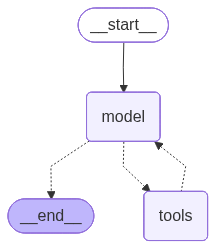

In [37]:
display(Image(research_agent.get_graph().draw_mermaid_png()))

`config_data` will be passed into the model in a raw form.

Now we make the prompt the model will respond to. Few shot prompting is used here to clarify exactly what we want to the model.

In [ ]:
# TODO: Set up dynamic prompt generation function incorporating few-shot examples
# and formatting based on the dynamic number of CVEs being processed.
def dynamic_prompt_generator(state) -> str:
    def reference_formater(refs: list, raw: list) -> str:
        unified_sources = zip(refs, raw)

        all_text = ""

        for ref, source_text in unified_sources:
            single_block = f"""\
            # Extracted from url {ref}
            {source_text}\n\n
            """
            all_text += single_block

        if all_text == "":
            all_text = "ALL REFERENCES REFUSED A CONNECTION, USE YOUR 'SEARXNG_SEARCH' TOOL TO FIND MORE INFORMATION."
    
        return all_text

    cve_data = state["cve_blob"]

    context_block = reference_formater(cve_data.get("reference_links", cve_data.get("all_references")))

    main_prompt = ChatPromptTemplate.from_template("""\
    You have received the following CVE: {cve_id}
    The following device is affected: {device_name}
    NIST describes this CVE as follows: {description}
    The following describes the CVSS metrics relating to {cve_id}:
        CVSS Version: {vuln_version}
        Score: {vuln_score}
        Severity: {vuln_severity}
    
    NIST lists the following websites as references for this CVE.
    <begin_page> and <end_page> tags encapsulate raw data scraped from these websites.
    
    ## NIST Sources
    <sources>
    {context}                                     
    </sources>
                                                   
    ## CPE Data
    CPE Data from NIST regarding vulnerable and non vulnerable configurations is provided below.
    <cpe_data>
    {config_data}
    </cpe_data>
                                                   
    ## Instructions
    1. Use the 'searxng_search' tool to find vendor advisories, exploit-db entries, or forum discussions.
    2. **Be Exhaustive:** Do not stop at the first result. Verify information across multiple sources if the first result is vague.
    3. If the search returns no results, try broader search terms (e.g., searching for the software component rather than the specific device).
    4. Once you have sufficient information to answer the Objective questions with confidence, call the 'submit_final_report' tool with your structured findings.
                                                   
    ## Objective
    You must be able to confidently answer all of the following questions before you can conclude your research:
    1. Is the CVE **exploitable**, if so how is it exploited?
    2. What is the **priority** of the CVE based on it's exploitablity (is there evidence of these attacks being used in the wild), how dire is the risk on a scale of 1-10? 
    3. Can the CVE be mitigated, and if so what are the step by step instructions to do so? Include specific items to click in a menu or commands to run. Be exhaustive.
    
    ## Output Instructions
    End the conversation after submitting the final report using the 'submit_final_report' tool.
""")

Before proceding test the model to make sure it can effectively use it's tool. *Note: JSON output will vary as we have not yet defined a schema for the model to follow*.

In [ ]:
# test on the new React Exploit
react_concatenated_score = """\
            Score Version: V3
            Score Value: 10.0
            Severity: CRITICAL
            """

react_exploit = {
    "device": "React Server",
    "cve_id": "CVE-2025-55182",
    "description": "A pre-authentication remote code execution vulnerability exists in React Server Components versions 19.0.0, 19.1.0, 19.1.1, and 19.2.0 including the following packages: react-server-dom-parcel, react-server-dom-turbopack, and react-server-dom-webpack. The vulnerable code unsafely deserializes payloads from HTTP requests to Server Function endpoints.",
    # test with context and without context
    "reference_links": ["http://www.openwall.com/lists/oss-security/2025/12/03/4", 
                        "https://aws.amazon.com/blogs/security/china-nexus-cyber-threat-groups-rapidly-exploit-react2shell-vulnerability-cve-2025-55182/",
                        "https://news.ycombinator.com/item?id=46136026",
                        "https://react.dev/blog/2025/12/03/critical-security-vulnerability-in-react-server-components",
                        "https://www.cisa.gov/known-exploited-vulnerabilities-catalog?field_cve=CVE-2025-55182",
                        "https://www.facebook.com/security/advisories/cve-2025-55182",
                        ],
    # "reference_links": [],
    "score_data": react_concatenated_score
    }

test_chain = direct_load | research_agent
result = await test_chain.ainvoke(react_exploit)
print(result)

{'messages': [AIMessage(content='{"error":"No CVE was provided. Please specify the CVE identifier (e.g., CVE-2023-12345) and any related context you have so that I can research the exact fix or workaround for you."}', additional_kwargs={}, response_metadata={'model': 'gpt-oss:20b', 'created_at': '2025-12-11T04:24:48.679155Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3902940584, 'load_duration': 1374083667, 'prompt_eval_count': 633, 'prompt_eval_duration': 13135750, 'eval_count': 49, 'eval_duration': 565176458, 'logprobs': None, 'model_name': 'gpt-oss:20b', 'model_provider': 'ollama'}, id='lc_run--019b0ba7-7de6-70e2-aaa1-362bd1b9dad5-0', usage_metadata={'input_tokens': 633, 'output_tokens': 49, 'total_tokens': 682})]}
